# Minecraft Mob Behavior Predictions


#### Leading Question:

Can the characteristics of Minecraft mobs be used to predict whether a mob is hostile or peaceful?

Dividing mobs into two groups, we chose to use classification to determine the outcome using a Kaggle dataset on Minecraft mobs. Mobs are any other moving figure in Minecraft that is not a player, for example, pigs, zombies, spiders, villagers, etc. Mob behavior is imperative in Minecraft gameplay as a mob can threaten players, or remain passive. By analyzing the relationship between players and mobs along with other details, we tested whether game design patterns can be learned from data through machine learning.

Using the mob data from Kaggle, we will use features explaining the design of mob behavior. These included variables such as health, damage, spawning, reproduction, etc.. Additionally, we paired our research with the Data Science lifecycle which provided specific questions, exploratory analysis, machine learning models, and evaluation of these models. Connecting to the course, we will use a Decision Tree and a Random Forest to show the final classifications.



## Step 1: Imports

In [52]:
# Imports
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import metrics

## Step 2: Load Dataset


The dataset is loaded from Kaggle Hub. It is a 2023 dataset covering Minecraft Blocks, Items, Mobs, and Biomes.

Documentation:
- https://www.kaggle.com/datasets/madelinee/minecraft-blocks-items-mobs-biomes-etc?resource=download&select=Mobs.csv

In [53]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("madelinee/minecraft-blocks-items-mobs-biomes-etc")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'minecraft-blocks-items-mobs-biomes-etc' dataset.
Path to dataset files: /kaggle/input/minecraft-blocks-items-mobs-biomes-etc


In [54]:
mobs_file_path = os.path.join(path, "Mobs.csv")

if os.path.exists(mobs_file_path):
    mobs_df = pd.read_csv(mobs_file_path)
    display(mobs_df.head())
else:
    print(
        f"{mobs_file_path} does not exist. "
        "Check the printed directory tree for the exact subfolder."
    )

print(f"Dataset shape: {mobs_df.shape}")

,ID,name,behaviorTypes,spawnBehavior,healthPoints,maxDamage,debutDate,minecraftVersion,reproductiveRequirement
0,1,sniffer_egg,Peaceful,Player Summoned,0,0.0,2023-06-07T00:00:00,1.20.0,NaN
1,2,turtle_egg,Peaceful,Player Summoned,0,0.0,2018-07-18T00:00:00,1.13.0,NaN
2,3,bat,Peaceful,Random,6,NaN,2012-10-25T00:00:00,1.4.2,NaN
3,4,blaze,Hostile,On Load,20,6.0,2011-11-18T00:00:00,1.0.0,NaN
4,5,chicken,Peaceful,Random,4,NaN,2011-11-18T00:00:00,1.0.0,Wheat Seeds


Dataset shape: (78, 9)


## Step 3: Data Exploration

In [55]:
# Info
mobs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       78 non-null     int64  
 1   name                     78 non-null     object 
 2   behaviorTypes            78 non-null     object 
 3   spawnBehavior            78 non-null     object 
 4   healthPoints             78 non-null     int64  
 5   maxDamage                56 non-null     float64
 6   debutDate                78 non-null     object 
 7   minecraftVersion         78 non-null     object 
 8   reproductiveRequirement  24 non-null     object 
dtypes: float64(1), int64(2), object(6)
memory usage: 5.6+ KB


In [56]:
# Describe
mobs_df.describe()

,ID,healthPoints,maxDamage
count,78.000000,78.000000,56.000000
mean,39.500000,31.358974,7.803571
std,22.660538,68.010117,10.971732
min,1.000000,0.000000,0.000000
25%,20.250000,10.000000,2.750000
50%,39.500000,16.000000,5.000000
75%,58.750000,23.000000,8.000000
max,78.000000,500.000000,68.000000


In [57]:
# Check for missing values (shouldn't be too small since it's a smaller dataset)
print("n\Missing Values: ")
mobs_df.isna().sum()

n\Missing Values: 


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_30947/3902373606.py:2: SyntaxWarning: invalid escape sequence '\M'
  print("n\Missing Values: ")


,0
ID,0
name,0
behaviorTypes,0
spawnBehavior,0
healthPoints,0
maxDamage,22
debutDate,0
minecraftVersion,0
reproductiveRequirement,54


In [58]:
mobs_df.head(10)

,ID,name,behaviorTypes,spawnBehavior,healthPoints,maxDamage,debutDate,minecraftVersion,reproductiveRequirement
0,1,sniffer_egg,Peaceful,Player Summoned,0,0.0,2023-06-07T00:00:00,1.20.0,NaN
1,2,turtle_egg,Peaceful,Player Summoned,0,0.0,2018-07-18T00:00:00,1.13.0,NaN
2,3,bat,Peaceful,Random,6,NaN,2012-10-25T00:00:00,1.4.2,NaN
3,4,blaze,Hostile,On Load,20,6.0,2011-11-18T00:00:00,1.0.0,NaN
4,5,chicken,Peaceful,Random,4,NaN,2011-11-18T00:00:00,1.0.0,Wheat Seeds
5,6,dolphin,Conditional,Random,10,3.0,2018-07-18T00:00:00,1.13.0,NaN
6,7,endermite,Hostile,Player Summoned,8,2.0,2014-09-02T00:00:00,1.8.0,NaN
7,8,guardian,Hostile,On Load,30,6.0,2014-09-02T00:00:00,1.8.0,NaN
8,9,guardian_elder,Hostile,On Load,80,8.0,2014-09-02T00:00:00,1.8.0,NaN
9,10,phantom,Hostile,Night,20,2.0,2018-07-18T00:00:00,1.13.0,NaN


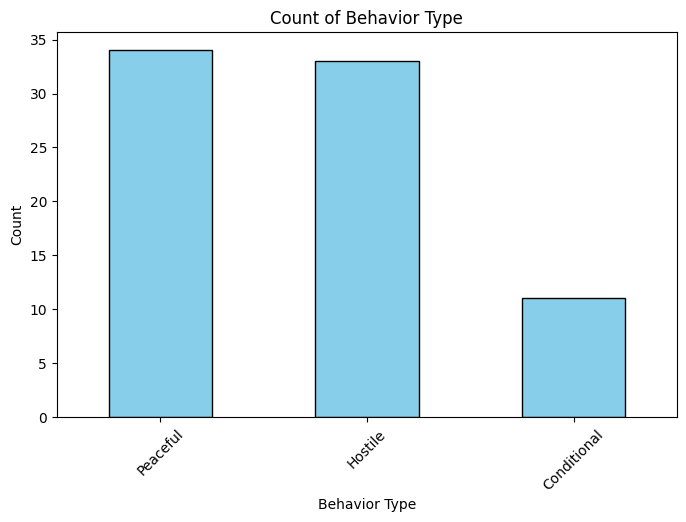

In [59]:
behavior_types = mobs_df['behaviorTypes'].value_counts()

plt.figure(figsize=(8, 5))
behavior_types.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Count of Behavior Type")
plt.xlabel("Behavior Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Addressing the "Conditional" category

So we have a category called conditional. The behavior of these creatures is "conditional" on the player's behavior. Since conditional means the creature has the ability to be hostile, we will label them under the hostile category.

In other words, conditional animals are not always hostile, but conditional animals can be hostile. Since peaceful creatures are unable to be hostile, we can't put conditional under peaceful.

In [60]:
# Change 'Conditional' behavior types to 'Hostile'
mobs_df['behaviorTypes'] = mobs_df['behaviorTypes'].replace('Conditional', 'Hostile')

# Verify the changes
mobs_df['behaviorTypes'].value_counts()

,count
behaviorTypes,
Hostile,44
Peaceful,34


## Step 4: Clean & Prepare the Data

In [61]:
# Step 1: Separte features (X) and target (y)
y = mobs_df['behaviorTypes']
X = mobs_df.drop('behaviorTypes', axis=1).copy()

In [62]:
# Step 2: Calculating prevalence to prevent guessing
prevalence = y.value_counts(normalize=True)
print("Class Prevalence: \n")
print(prevalence)

majority_class = prevalence.idxmax()
baseline_accuracy = prevalence.max()

print(f"\nMajority Class: {majority_class}")
print(f"Baseline Accuracy to beat: {baseline_accuracy:.2%}")

Class Prevalence: 

behaviorTypes
Hostile     0.564103
Peaceful    0.435897
Name: proportion, dtype: float64

Majority Class: Hostile
Baseline Accuracy to beat: 56.41%


## Collapse Factor Levels

In [63]:
mobs_df.head()

,ID,name,behaviorTypes,spawnBehavior,healthPoints,maxDamage,debutDate,minecraftVersion,reproductiveRequirement
0,1,sniffer_egg,Peaceful,Player Summoned,0,0.0,2023-06-07T00:00:00,1.20.0,NaN
1,2,turtle_egg,Peaceful,Player Summoned,0,0.0,2018-07-18T00:00:00,1.13.0,NaN
2,3,bat,Peaceful,Random,6,NaN,2012-10-25T00:00:00,1.4.2,NaN
3,4,blaze,Hostile,On Load,20,6.0,2011-11-18T00:00:00,1.0.0,NaN
4,5,chicken,Peaceful,Random,4,NaN,2011-11-18T00:00:00,1.0.0,Wheat Seeds


In [64]:
# Inspect the value counts of categorical features to decide if we need to collapse factors
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"--- {col} ---")
    print(X[col].value_counts(dropna=False))
    print("\n")

--- name ---
name
sniffer_egg        1
turtle_egg         1
bat                1
blaze              1
chicken            1
                  ..
wolf_tame          1
drowned            1
husk               1
zombie             1
zombie_villager    1
Name: count, Length: 78, dtype: int64


--- spawnBehavior ---
spawnBehavior
Random             43
On Load            14
Player Summoned    11
Night              10
Name: count, dtype: int64


--- debutDate ---
debutDate
2011-11-18T00:00:00    22
2018-07-18T00:00:00     9
2019-04-23T00:00:00     6
2012-10-25T00:00:00     5
2014-09-02T00:00:00     5
2020-06-23T00:00:00     5
2016-11-14T00:00:00     4
2022-06-07T00:00:00     4
2021-06-08T00:00:00     3
2023-06-07T00:00:00     3
2013-07-01T00:00:00     3
2016-06-08T00:00:00     3
2017-06-07T00:00:00     2
2012-03-01T00:00:00     2
2019-12-10T00:00:00     1
2016-02-29T00:00:00     1
Name: count, dtype: int64


--- minecraftVersion ---
minecraftVersion
1.0.0     22
1.13.0     9
1.14.0     6
1.8.0 

## Feature Engineering



We chose to drop the columns 'name' and collapse 'reproductiveRequirement' into a binary feature. 'Name' has around 72 unique identifiers (one per row) and is not helpful in the model since the name is arbitrary and 72 unique values does not contribute to information gain and would have a high gini.

'reproductiveRequirement' contained string or NaN values so it was easiest to just collapse into a binary feature since the individual requirements were not as necessary as if the mob required an item for reproduction or not.

We also dropped 'maxDamage' since it is a leakage feature. Only hostile animals have a maxDamage value so it would be a dead giveaway

In [81]:
# Drop the 'name' column as it's a unique identifier and won't help the model
X = X.drop('name', axis=1, errors='ignore')

# Drop maxDamage as it's a leakage feature
X = X.drop('maxDamage', axis=1, errors='ignore')

# Collapse 'reproductiveRequirement' into a binary feature: 1 if it can reproduce (not NaN), 0 otherwise
if 'reproductiveRequirement' in X.columns:
    X['canReproduce'] = X['reproductiveRequirement'].notna().astype(int)
    X = X.drop('reproductiveRequirement', axis=1)

# Display the updated dataframe to verify changes
display(X.head())

,spawnBehavior,healthPoints,canReproduce,debutYear
0,Player Summoned,0,0,2023
1,Player Summoned,0,0,2018
2,Random,6,0,2012
3,On Load,20,0,2011
4,Random,4,1,2011


## More Cleaning

ID Column - This column is also arbitrary and only serves as a unique identifier, which won't help the model.

maxDamage - This column had missing values which needed to be replaced with the integer 0

debutDate - Day/Month/year releases in Minecraft aren't very necessary since most of the mobs have been around for a long time and the new ones only come out each new year.

minecraftVersion - This won't have an impact. Hostile and non-hostile mobs have been present in all versions.

This ties up loose ends and only keeps the necessary columns in a clean and organized DataFrame.

In [82]:
# Drop the ID column
X = X.drop('ID', axis=1, errors='ignore')

# Extract the year from 'debutDate' as a new numerical feature
if 'debutDate' in X.columns:
    X['debutYear'] = pd.to_datetime(X['debutDate']).dt.year

# Drop the high-cardinality columns
X = X.drop(['debutDate', 'minecraftVersion'], axis=1, errors='ignore')

# Display the final features and verify no missing values remain
display(X.head())
print("\nMissing values after cleaning:")
print(X.isna().sum())

,spawnBehavior,healthPoints,canReproduce,debutYear
0,Player Summoned,0,0,2023
1,Player Summoned,0,0,2018
2,Random,6,0,2012
3,On Load,20,0,2011
4,Random,4,1,2011



Missing values after cleaning:
spawnBehavior    0
healthPoints     0
canReproduce     0
debutYear        0
dtype: int64


## Step 5: Partitioning the Data

With only 78 rows, if we used a smaller training set (like 50%), the model might not see enough examples of rare mobs to learn. If we used a smaller test set (like 5%), a single mistake by the model would swing the accuracy percentage wildly, making our evaluation unreliable. This 60/20/20 balance is good for this amount of data.

In [83]:
# Split data into 80% temp (for train/val) and 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
# Split temp into 60% train and 20% validation (which is 25% of the 80% temp data)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp,
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (46, 4)
Validation set shape: (16, 4)
Test set shape: (16, 4)


## Pipeline

This pipeline is similar to the one we used for the mushroom lab, but we adapted it to the mob dataset and used 5-fold CV.

In [84]:
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Build decision tree pipeline with OneHotEncoder preprocessing
# We use OneHotEncoder because 'spawnBehavior' has no inherent order.
dt_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ],
        remainder='passthrough'
    )),
    ('classifier', DecisionTreeClassifier(random_state=42, criterion='gini', max_depth=3))
])

# Evaluate with 5-fold cross-validation on training data
cv_scores = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(f"5-Fold CV Accuracy Scores: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean():.2%} (+/- {cv_scores.std() * 2:.2%})")

# Fit final model on full training data
dt_model = dt_pipeline.fit(X_train, y_train)
print("\nPipeline fitted successfully on the training data!")

5-Fold CV Accuracy Scores: [0.4        0.66666667 0.55555556 0.77777778 0.77777778]
Average CV Accuracy: 63.56% (+/- 28.75%)

Pipeline fitted successfully on the training data!


## Evaluation Metrics

Scoring the model performance. We will use these scores to build the confusion matrix later on. It is all called from the scikit-learn metrics library.

In [85]:
# Generate pedictions and predicted probabilities
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)

# Train Set
train_pred = dt_model.predict(X_train)
test_pred = dt_model.predict(X_test)

print("Train accuracy:", metrics.accuracy_score(y_train, train_pred))
print("Test accuracy:", metrics.accuracy_score(y_test, test_pred))

# Put into a DataFrame
results = pd.DataFrame({
    'target': y_test,
    'pred': dt_pred,
    'prob_peaceful': dt_prob[: ,0],
    'prob_hostile': dt_prob[:, 1]
})


Train accuracy: 0.9347826086956522
Test accuracy: 0.6875


## Confusion Matrix

Shows where the model is getting confused

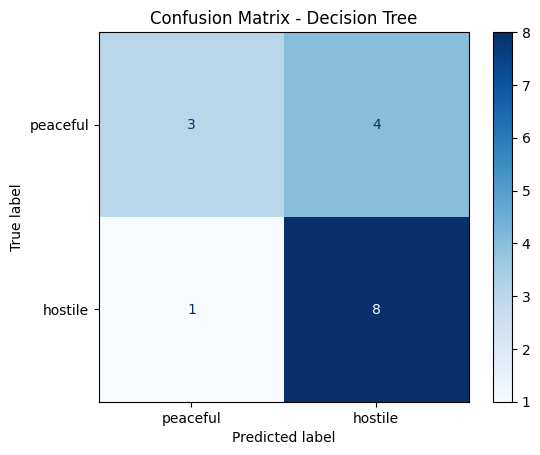

In [86]:
# Confusion Matrix
cm = confusion_matrix(y_test, dt_pred, labels=['Peaceful', 'Hostile'])

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["peaceful", "hostile"],
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

##### See above, only 16 mobs because the matrix only shows the test set

However, it only made 3 mistakes out of 16 which is pretty good, but we can probably improve it

## True Positive Rate + False Positive Rate

In [87]:
# Get metrics
tn, fp, fn, tp = metrics.confusion_matrix(
    y_test,
    dt_pred,
    labels=["Peaceful", "Hostile"],
).ravel()

# Calculate TPR and FPR
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

True Positive Rate (TPR): 0.8889
False Positive Rate (FPR): 0.5714


## Classification Report

In [88]:
# Print classification report
print(metrics.classification_report(y_test, dt_pred))

# Print CV scores
print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std. CV accuracy:", cv_scores.std())

              precision    recall  f1-score   support

     Hostile       0.67      0.89      0.76         9
    Peaceful       0.75      0.43      0.55         7

    accuracy                           0.69        16
   macro avg       0.71      0.66      0.65        16
weighted avg       0.70      0.69      0.67        16

CV scores: [0.4        0.66666667 0.55555556 0.77777778 0.77777778]
Mean CV accuracy: 0.6355555555555555
Std. CV accuracy: 0.14374188114485537


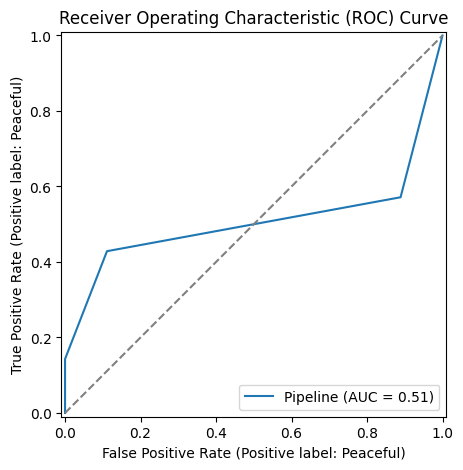


AUC (using 'Peaceful' as positive class): 0.5079


In [89]:
# Plot the ROC Curve
fig, ax = plt.subplots(figsize=(7, 5))
metrics.RocCurveDisplay.from_estimator(dt_model, X_test, y_test, ax=ax)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--') # Add diagonal baseline
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.show()

# Calculate AUC explicitly
# dt_model.classes_ contains ['Hostile', 'Peaceful']
# We will use the probabilities of the second class (index 1) to calculate AUC
pos_class = dt_model.classes_[1]
y_test_binary = (y_test == pos_class).astype(int)
auc_score = metrics.roc_auc_score(y_test_binary, dt_prob[:, 1])

print(f"\nAUC (using '{pos_class}' as positive class): {auc_score:.4f}")

# How can we get better?

#### Hyperparameter Tuning

Using GridSearchCV to find the optimal parameters for the Decision Tree to reduce overfitting and improve test accuracy.

In [90]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid to search over
# Note: We use 'classifier__' prefix because the DecisionTree is inside a Pipeline
param_grid = {
    'classifier__max_depth': [2, 3, 4, 5, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__criterion': ['gini', 'entropy']
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best CV score
print("Best Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_:.2%}")

# Get the best model and evaluate on the test set
best_dt_model = grid_search.best_estimator_
optimized_pred = best_dt_model.predict(X_test)

print(f"\nOptimized Test Accuracy: {metrics.accuracy_score(y_test, optimized_pred):.2%}")
print("\nOptimized Classification Report:")
print(metrics.classification_report(y_test, optimized_pred))

Best Parameters Found:
  classifier__criterion: entropy
  classifier__max_depth: 3
  classifier__min_samples_leaf: 4
  classifier__min_samples_split: 10

Best Cross-Validation Accuracy: 80.00%

Optimized Test Accuracy: 81.25%

Optimized Classification Report:
              precision    recall  f1-score   support

     Hostile       1.00      0.67      0.80         9
    Peaceful       0.70      1.00      0.82         7

    accuracy                           0.81        16
   macro avg       0.85      0.83      0.81        16
weighted avg       0.87      0.81      0.81        16



## 2nd Classification Report Post Hyperparameter Tuning

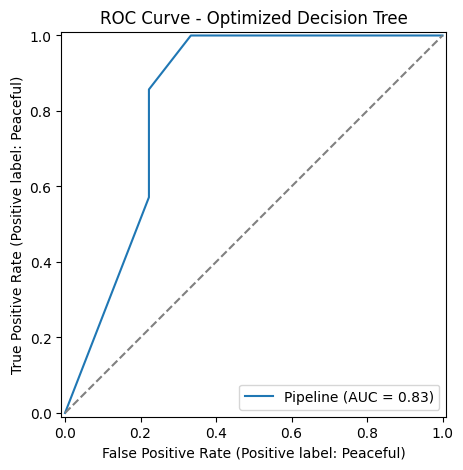


Optimized AUC (using 'Peaceful' as positive class): 0.8333


In [91]:
# Get predicted probabilities for the optimized model
optimized_prob = best_dt_model.predict_proba(X_test)

# Plot the ROC Curve for the optimized model
fig, ax = plt.subplots(figsize=(7, 5))
metrics.RocCurveDisplay.from_estimator(best_dt_model, X_test, y_test, ax=ax)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--') # Add diagonal baseline
plt.title('ROC Curve - Optimized Decision Tree')
plt.show()

# Calculate AUC explicitly
pos_class = best_dt_model.classes_[1]
y_test_binary = (y_test == pos_class).astype(int)
optimized_auc = metrics.roc_auc_score(y_test_binary, optimized_prob[:, 1])

print(f"\nOptimized AUC (using '{pos_class}' as positive class): {optimized_auc:.4f}")

## Visualize the Decision Tree
Let's look at the actual rules the model learned to separate Hostile and Peaceful mobs.

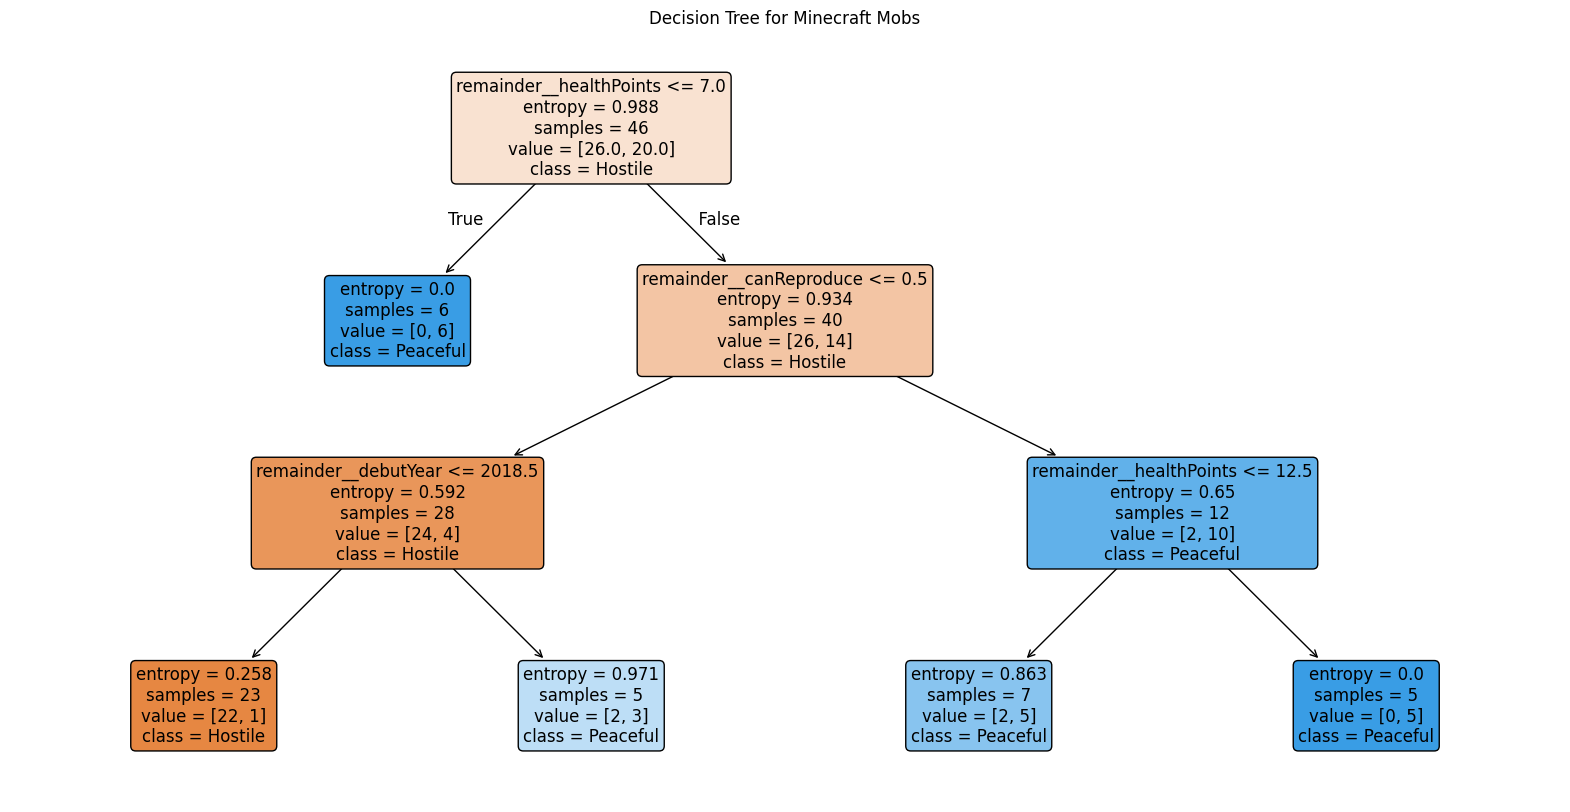

In [92]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Extract the preprocessor and the decision tree classifier from the best pipeline
preprocessor = best_dt_model.named_steps['preprocessor']
classifier = best_dt_model.named_steps['classifier']

# Get the feature names after OneHotEncoding
feature_names = preprocessor.get_feature_names_out()

# Set up the plot
plt.figure(figsize=(20, 10))

# Plot the tree
plot_tree(
    classifier,
    feature_names=feature_names,
    class_names=classifier.classes_,
    filled=True,
    rounded=True,
    fontsize=12
)

plt.title('Decision Tree for Minecraft Mobs')
plt.show()

## Random Forest
Let's see if an ensemble of trees (Random Forest) can improve our test accuracy over a single Decision Tree.

In [93]:
from sklearn.ensemble import RandomForestClassifier

# Build Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ],
        remainder='passthrough'
    )),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100, max_depth=3))
])

# Evaluate with 5-fold cross-validation on training data
rf_cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(f"Random Forest 5-Fold CV Accuracy: {rf_cv_scores.mean():.2%} (+/- {rf_cv_scores.std() * 2:.2%})")

# Fit on the full training data and evaluate on the test set
rf_model = rf_pipeline.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print(f"\nRandom Forest Test Accuracy: {metrics.accuracy_score(y_test, rf_pred):.2%}")
print("\nRandom Forest Classification Report:")
print(metrics.classification_report(y_test, rf_pred))

Random Forest 5-Fold CV Accuracy: 71.78% (+/- 22.29%)

Random Forest Test Accuracy: 87.50%

Random Forest Classification Report:
              precision    recall  f1-score   support

     Hostile       1.00      0.78      0.88         9
    Peaceful       0.78      1.00      0.88         7

    accuracy                           0.88        16
   macro avg       0.89      0.89      0.88        16
weighted avg       0.90      0.88      0.88        16



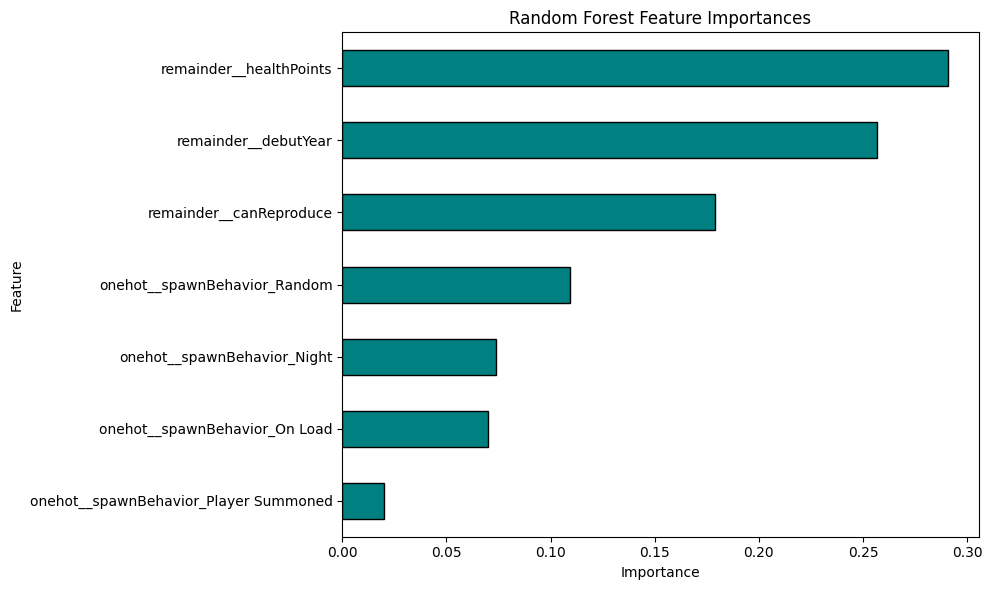

In [94]:
# Extract the preprocessor and the random forest classifier from the pipeline
rf_preprocessor = rf_model.named_steps['preprocessor']
rf_classifier = rf_model.named_steps['classifier']

# Get the feature names after OneHotEncoding
rf_feature_names = rf_preprocessor.get_feature_names_out()

# Get feature importances
importances = rf_classifier.feature_importances_

# Create a pandas Series for easy plotting
feature_importances = pd.Series(importances, index=rf_feature_names).sort_values(ascending=True)

# Plot the feature importances
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## First Tree in the forest

It's difficult to visualize a full random forest so we'll just look at one of the trees.

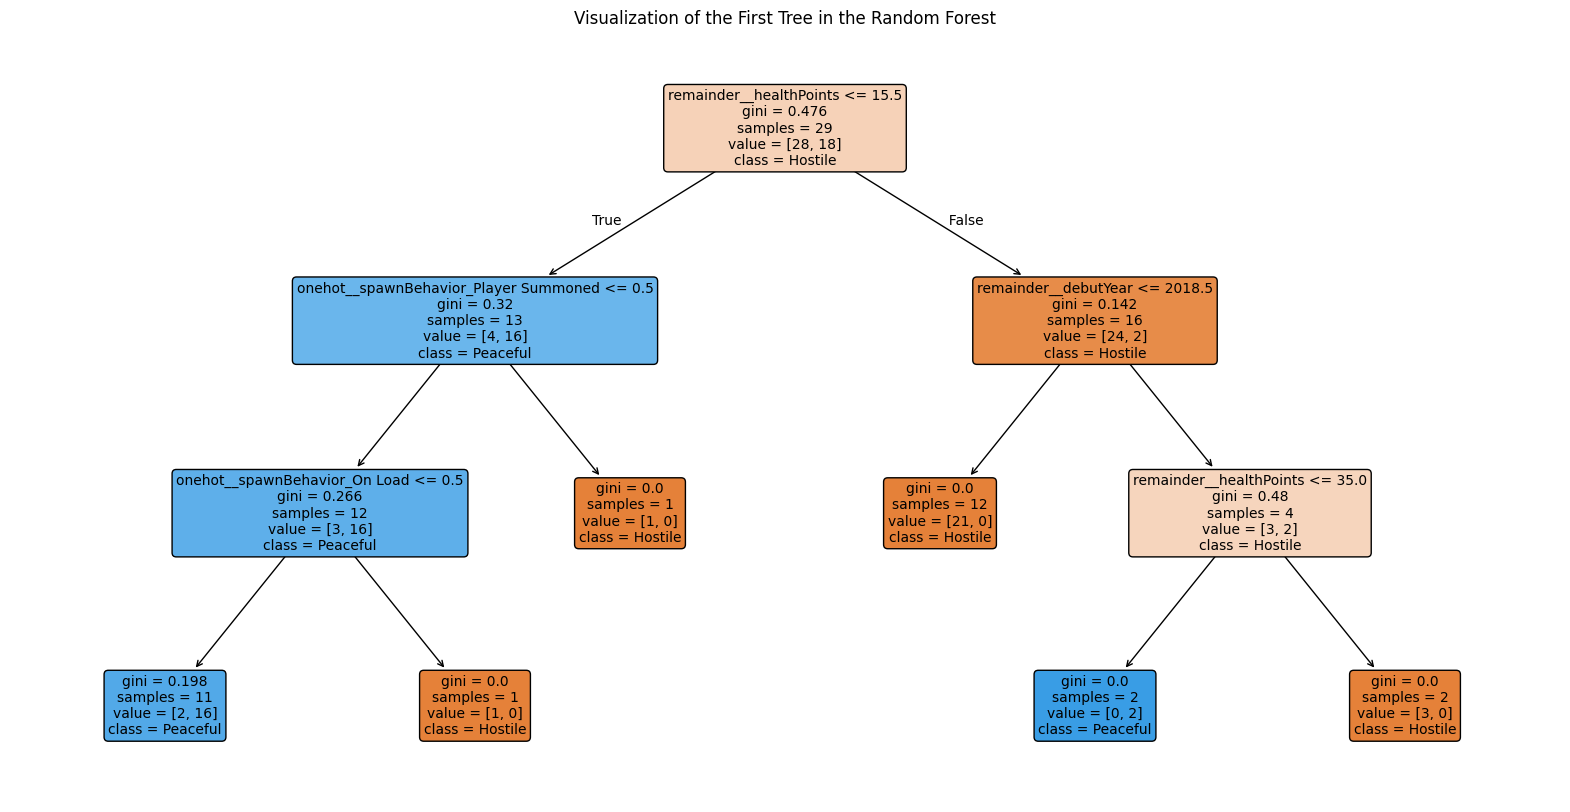

In [95]:
# Extract the first tree from the Random Forest ensemble
first_tree = rf_model.named_steps['classifier'].estimators_[0]

# Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(
    first_tree,
    feature_names=rf_feature_names,
    class_names=rf_model.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title('Visualization of the First Tree in the Random Forest')
plt.show()

## Inspecting Misclassifications
Let's see which specific mobs the Random Forest model misclassified by joining the errors back to the original dataset.

In [96]:
# Find indices where the actual label doesn't match the prediction
misclassified_mask = y_test != rf_pred
misclassified_indices = y_test[misclassified_mask].index

# Get the original rows for the misclassified mobs
misclassified_mobs = mobs_df.loc[misclassified_indices].copy()

# Add the model's incorrect predictions to the dataframe for comparison
misclassified_mobs['Predicted_Behavior'] = rf_pred[misclassified_mask]

# Display the names, actual behaviors, predicted behaviors, and key features
display(misclassified_mobs[['name', 'behaviorTypes', 'Predicted_Behavior', 'healthPoints', 'spawnBehavior']])


,name,behaviorTypes,Predicted_Behavior,healthPoints,spawnBehavior
52,killer rabbit,Hostile,Peaceful,3,Player Summoned
33,hoglin,Hostile,Peaceful,40,Random


We only got two wrong which were the pufferfish and the Killer Rabbit! Pufferfish are even deceptive in real life. In Japan, sushi chefs need special licenses just to cook them and it takes years of training. In Minecraft, they would be under the conditional category and only encountered in the water. Killer rabbit might take some more research to figure out why it was wrong, but only 2 incorrect predictions is pretty good!

## Confusion Matrix Comparison
Let's compare the mistakes made by the optimized Decision Tree versus the Random Forest.

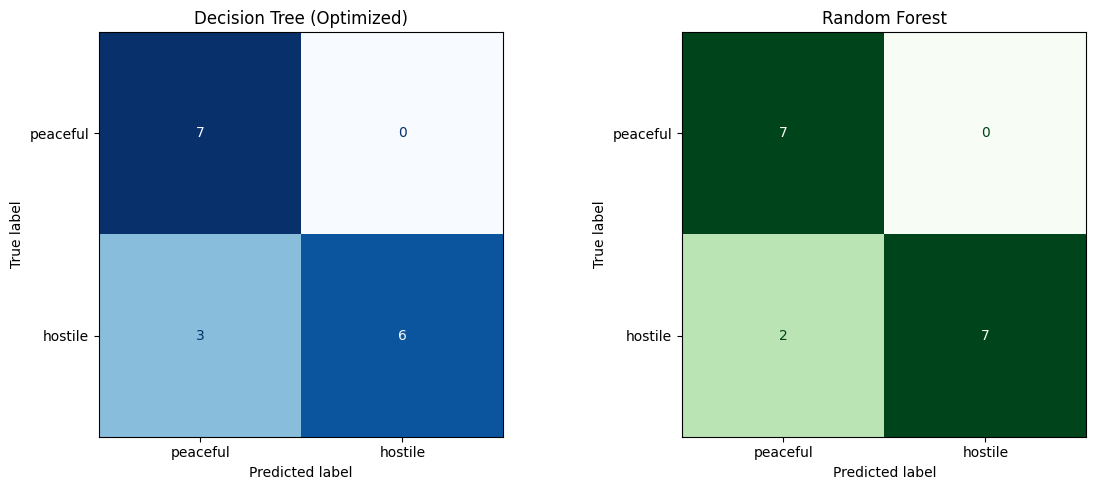

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrices
cm_dt = confusion_matrix(y_test, optimized_pred, labels=['Peaceful', 'Hostile'])
cm_rf = confusion_matrix(y_test, rf_pred, labels=['Peaceful', 'Hostile'])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Decision Tree CM
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['peaceful', 'hostile'])
disp_dt.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Decision Tree (Optimized)')

# Plot Random Forest CM
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['peaceful', 'hostile'])
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

## Final Model Comparison

The side-by-side confusion matrices show that both the optimized Decision Tree and the Random Forest perform well on distinguishing hostile from peaceful mobs, but the Random Forest reduces some of the individual classification errors by averaging across many shallow trees instead of relying on one strict set of decision rules. And as we saw earlier, it only got two wrong.

This suggests that while the Decision Tree provides a highly interpretable set of splits, the Random Forest offers slightly more stable generalization on unseen mobs. In particular, the ensemble model is less sensitive to unusual combinations of armor, health, or movement characteristics that may confuse a single tree.

However, both models still struggle with mobs whose features overlap behaviorally, showing that certain Minecraft mobs do not fall into perfectly separable categories based only on the selected attributes. Perhaps in a more robust dataset we would be able to pick features apart a bit better and have greater information gain.

## Conclusion

Utilizing the findings of methods and evaluation‚ we can conclude that Minecraft mob traits can be used to accurately predict whether a mob is Hostile or Peaceful․ Among the trained models‚ the random forest is the strongest model․ From these results‚ we can see that it is quite likely mob health‚ mob spawning‚ and mob reproduction are all correlated with whether a mob is classified as Hostile or Peaceful‚ and so Minecraft mob behavior can be predicted through machine learning techniques․ However‚ these conclusions should always be kept within the context of the model's limitations․ Since the training dataset is small‚ results can be sensitive to the train-test split‚ and should be viewed as less generalizable than results with larger datasets․ Other project decisions simplified the data‚ such as placing Conditional mobs in the Hostile group‚ and considering reproduction to be simply yes or no․ However‚ this approach loses some subtlety‚ and the model is only as good as the underlying features․ Any tactical differences in the gameplay not reflected in the dataset will not be accounted for in the predictions․ The downside to these concerns is that‚ despite the issues discussed‚ this project has demonstrated the entirety of a data science pipeline: question definition‚ data exploration‚ feature engineering‚ model selection and tuning‚ validation on unseen test data‚ and careful interpretation of results․ Most of all‚ we can conclude that a mob's characteristics are sufficient for a model‚ even a random forest‚ to classify behavior reasonably well․